In [1]:
from PIL import Image
import pytesseract

In [7]:
file_path = './image.png'
img = Image.open(file_path)

OSD Data: {'page_num': 0, 'orientation': 270, 'rotate': 90, 'orientation_conf': 10.28, 'script': 'Cyrillic', 'script_conf': 0.23}
Rotated image by -90 degrees.
Resized image to 2480x1751 to fit A4 page.
Pasted image onto A4 background at (0, 878).


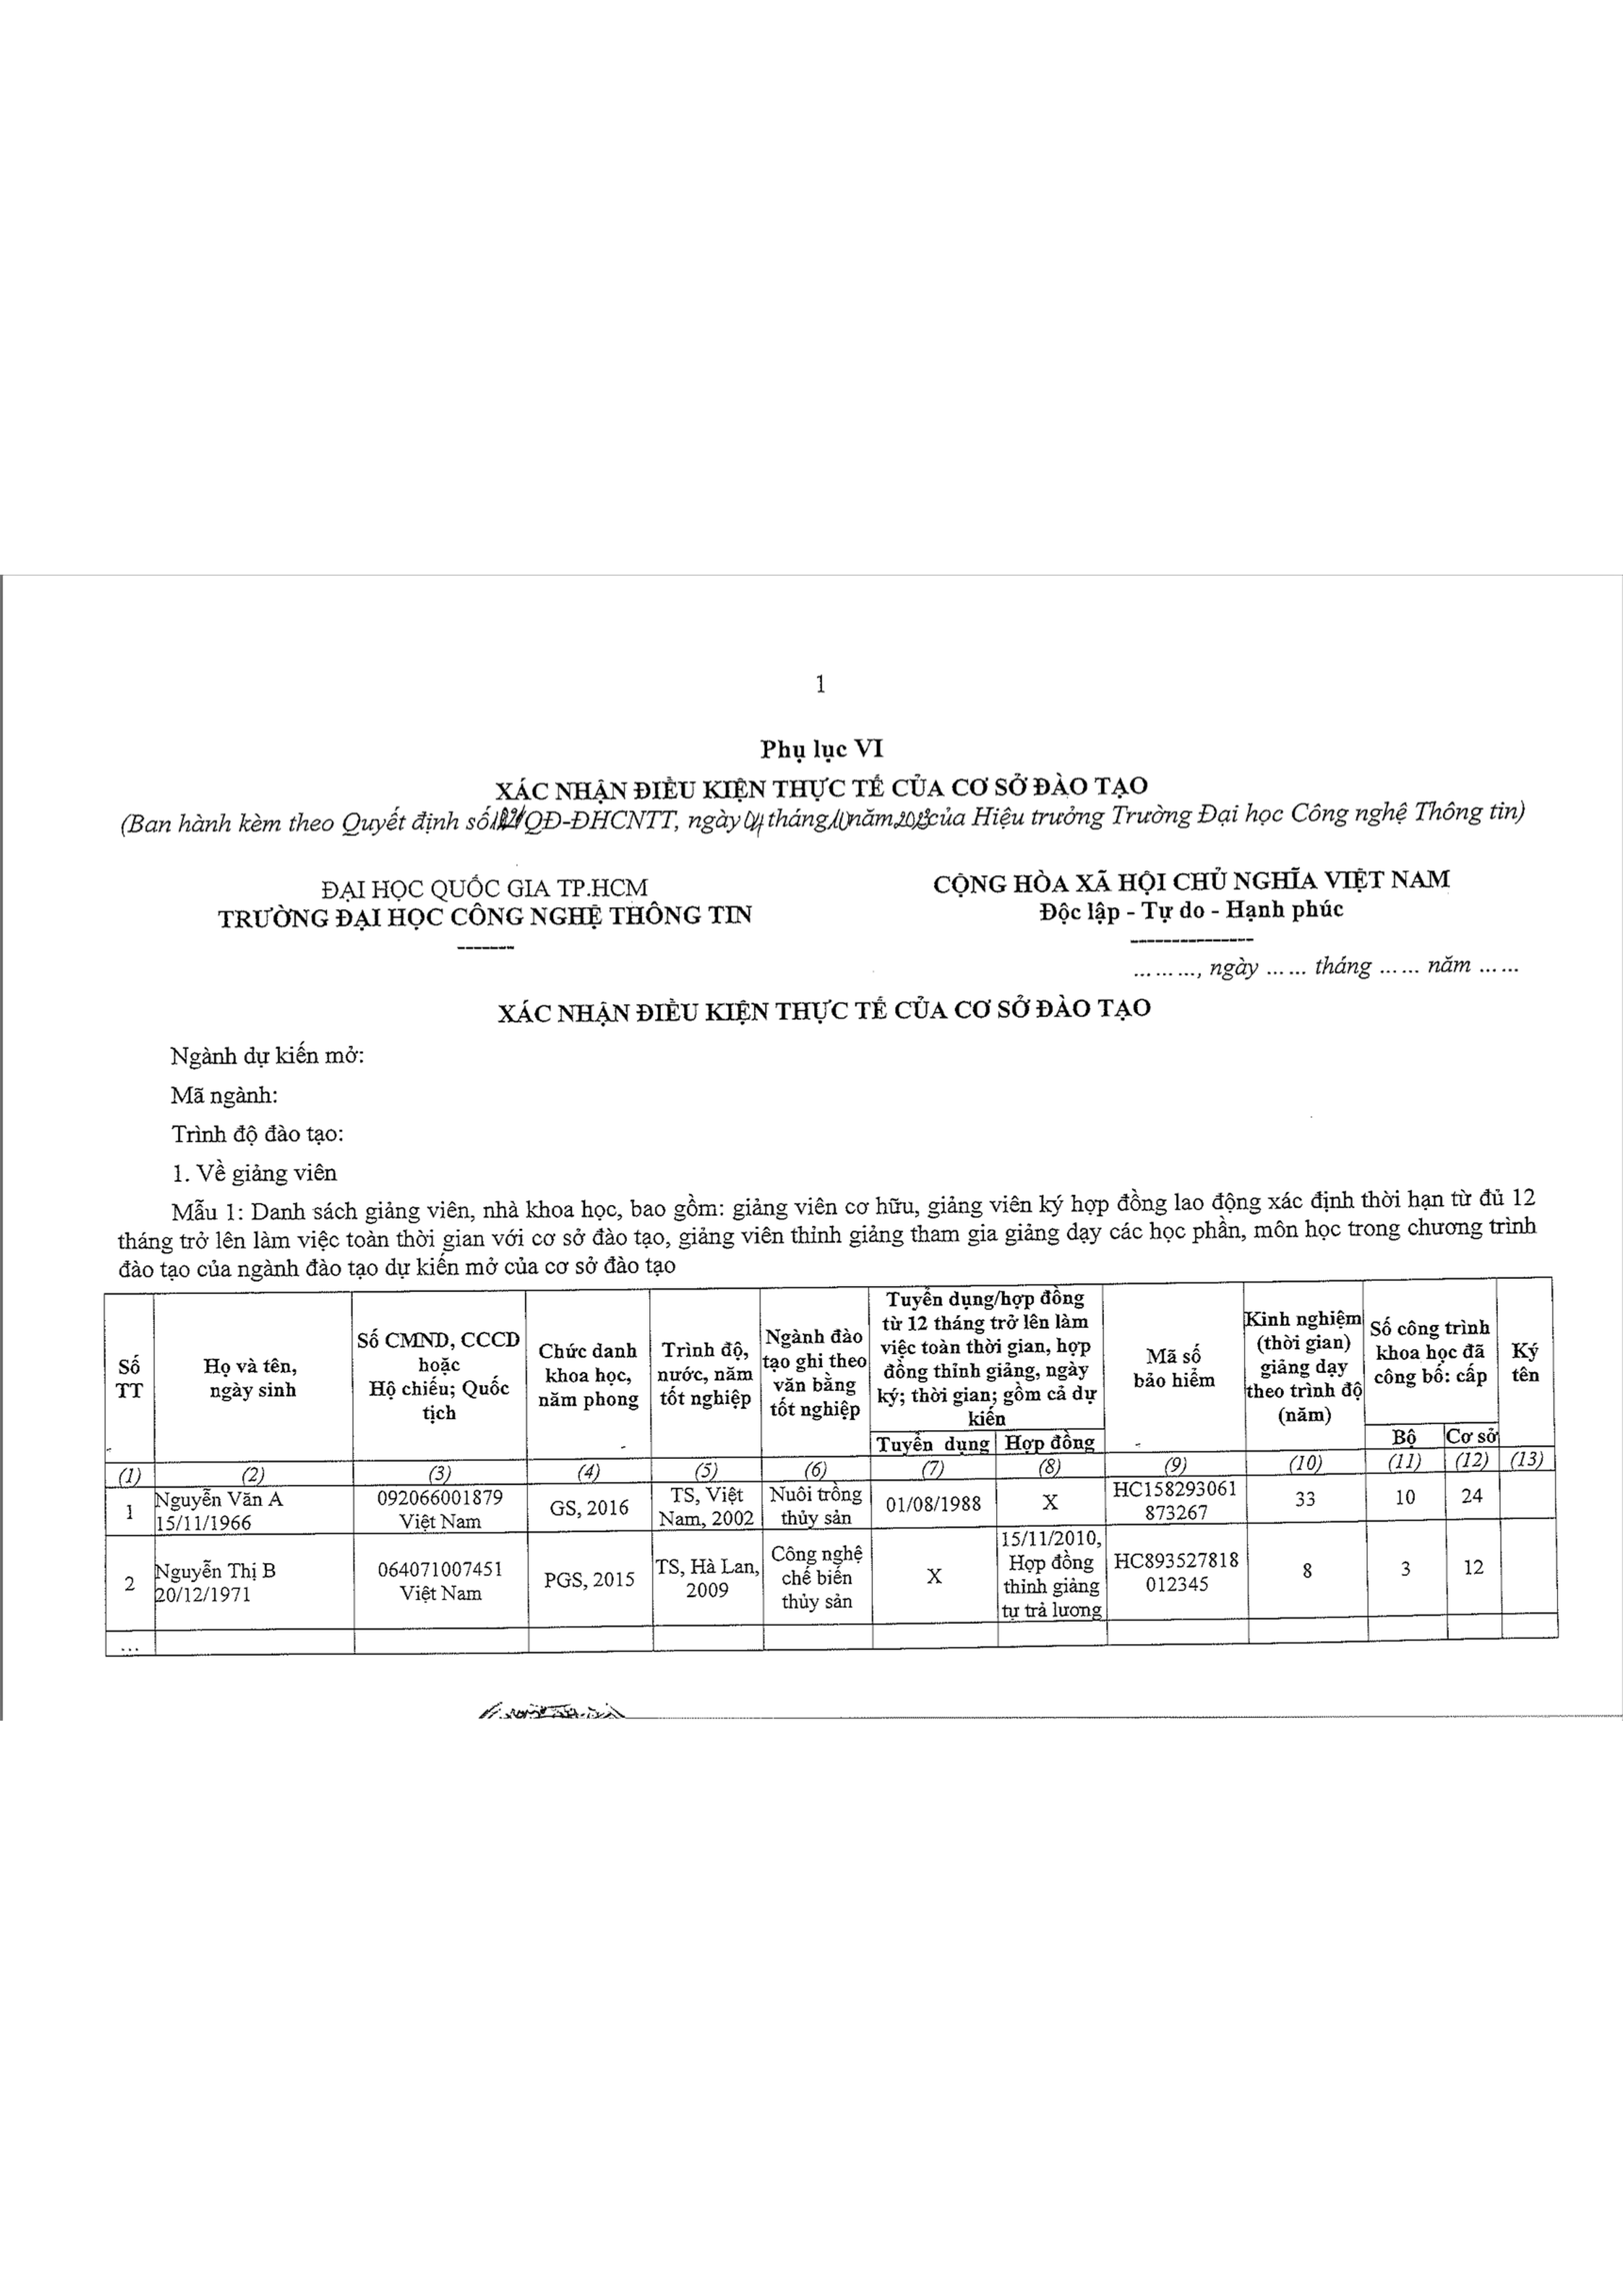

In [8]:

# Get orientation data directly as a dictionary
osd_dict = pytesseract.image_to_osd(img, output_type=pytesseract.Output.DICT)
print(f"OSD Data: {osd_dict}")

rotation_angle = osd_dict.get('rotate', 0)

# Rotate the image if OSD suggests a rotation
if rotation_angle != 0:
    # 'expand=True' makes sure the image is not cropped after rotation
    rotated_img = img.rotate(-1*rotation_angle, expand=True)
    print(f"Rotated image by {-1*rotation_angle} degrees.")
else:
    rotated_img = img
    print("No rotation needed.")

# --- Fit rotated image onto a blank A4 page ---

# A4 dimensions at 300 DPI (in pixels) for a standard portrait layout
A4_WIDTH_PX, A4_HEIGHT_PX = 2480, 3508

# Create a new white A4 background
a4_page = Image.new('RGB', (A4_WIDTH_PX, A4_HEIGHT_PX), 'white')

# Get dimensions of the (potentially rotated) image
img_width, img_height = rotated_img.size

# Calculate scaling factor to fit the image within the A4 page while maintaining aspect ratio
width_ratio = A4_WIDTH_PX / img_width
height_ratio = A4_HEIGHT_PX / img_height
scaling_factor = min(width_ratio, height_ratio)

# Calculate the new dimensions for the resized image
new_width = int(img_width * scaling_factor)
new_height = int(img_height * scaling_factor)

# Resize the image using a high-quality downsampling filter
resized_img = rotated_img.resize((new_width, new_height), Image.LANCZOS)
print(f"Resized image to {new_width}x{new_height} to fit A4 page.")

# Calculate position to paste the resized image in the center of the A4 background
paste_x = (A4_WIDTH_PX - new_width) // 2
paste_y = (A4_HEIGHT_PX - new_height) // 2

# Paste the resized image onto the A4 background
a4_page.paste(resized_img, (paste_x, paste_y))
print(f"Pasted image onto A4 background at ({paste_x}, {paste_y}).")

# Display the final A4-formatted image in the notebook output
a4_page
